In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sun.src.sun_post_process import PostProcessSun
from utils.styles import *
import pickle

In [132]:
pp = PostProcessSun('Output/results_30_30.pkl')
pp.extract_eigenfields()

Eigenfreuqncy 6: 14101.303243617258 + -2.8089738178401265e-09i


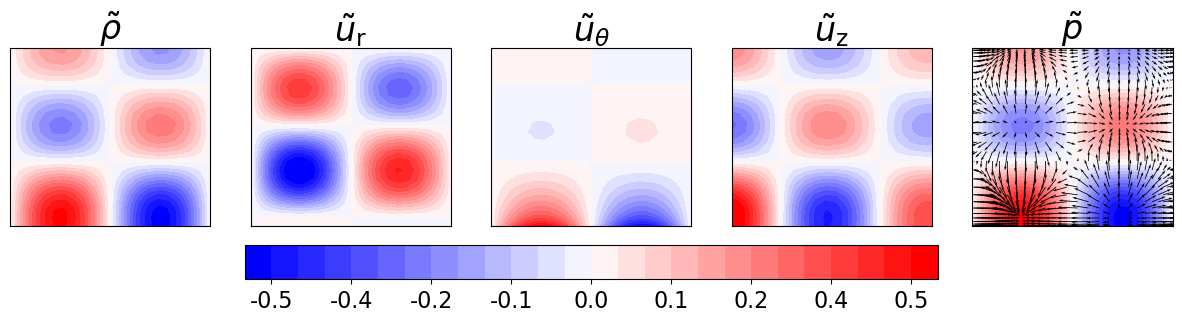

In [133]:
z = pp.data['AxialCoords']
r = pp.data['RadialCoords']
modes_map = cm.bwr
save_filename = 'test'
modesToPlot = slice(0, 8)


imode = 6
mode = pp.eigenfields[imode]
rs = mode.eigenfrequency.real
df = mode.eigenfrequency.imag

fig, axs = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
axs = axs.flatten()

titles = [
    r'$\tilde{\rho}$',
    r'$\tilde{u}_{\rm r}$',
    r'$\tilde{u}_{\theta}$',
    r'$\tilde{u}_{\rm z}$',
    r'$\tilde{p}$',
]

fields = [
    mode.eigen_rho,
    mode.eigen_ur,
    mode.eigen_utheta,
    mode.eigen_uz,
    mode.eigen_p,
]


vmin, vmax = -0.5, 0.5

for i, (ax, field, title) in enumerate(zip(axs, fields, titles)):
    cf = ax.contourf(
        z, r, field,
        levels=30,
        cmap=modes_map,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title)

    # Keep x-label only for bottom row (if needed adjust condition)
    # ax.set_xlabel(r'$z$')
    ax.set_xticks([])
    ax.set_yticks([])

# Create ONE shared colorbar
cbar = fig.colorbar(
    cf,
    ax=axs,
    format='%.1f',
    orientation='horizontal',
    pad=0.08   # increase = move further away
)

ax.quiver(
        z[1:-1], r[1:-1], mode.eigen_uz[1:-1], mode.eigen_ur[1:-1],
        angles='xy', scale_units='xy', scale=2, width=0.004
    )


# plt.tight_layout()

plt.savefig(
    'pictures/' + save_filename + '_modes_%i_%i_%i.pdf' %
    (pp.nStream, pp.nSpan, imode),
    bbox_inches='tight'
)

print(f"Eigenfreuqncy {imode}: {rs} + {df}i")


In [134]:
with open('analytical/analytical_eigenvalues.pkl', 'rb') as f:
    analytical = pickle.load(f)

analytical

array([ 4934.70314645,  8225.60546442,  8897.0924599 , 11066.50551677,
       12002.26721184, 13057.68685745, 14101.82177312, 14622.32800138,
       16112.82009757, 17035.44273414, 17273.85569656, 17732.17219049,
       18485.00421256, 20143.85420967, 20447.22997637, 20466.89373747,
       21764.66628178, 23101.03389415, 23770.68846678, 26323.53575687])

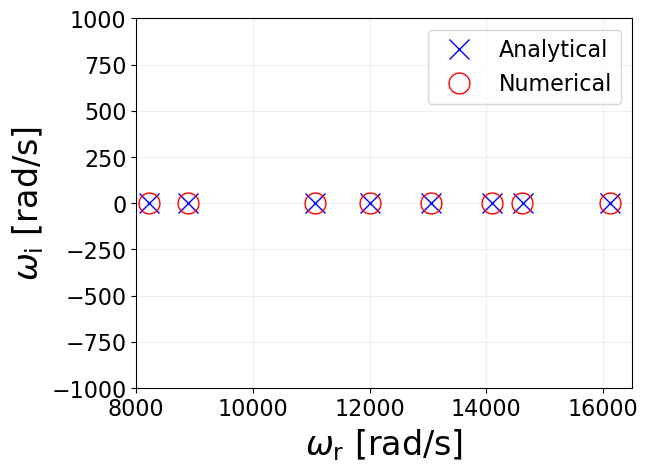

In [136]:
plt.figure()
plt.plot(analytical, analytical*0, 'x', mfc='none', ms=15, label='Analytical', c='blue')

# modes 3 and 4 are spurious
eigs = pp.data['Eigenfrequencies']
for ii,eig in enumerate(eigs):
    if ii == 0:
        plt.plot(eig.real, eig.imag, 'o', mfc='none', ms=15, label=r'Numerical', c='red')
    elif ii!=3 and ii!=4:
        plt.plot(eig.real, eig.imag, 'o', mfc='none', ms=15, c='red')
plt.legend()
plt.grid(alpha=0.2)
plt.xlim([8000, 16500])
plt.ylim([-1000, 1000])
plt.xlabel(r'$\omega_{\rm r}$ [rad/s]')
plt.ylabel(r'$\omega_{\rm i}$ [rad/s]')
plt.savefig('pictures/circularDuct_eigenvalueMap.pdf', bbox_inches='tight')
plt.show()